#  ASL Sign Language Recognition — MLP (Hand Landmark Based)
**Pipeline:** MediaPipe Hand Landmarks → Normalize → MLP Classifier

>  **Before running:** Add dataset `signnteam/asl-sign-language-pictures-minus-j-z` via *Notebook → Add Data*

##  Install Dependencies

In [3]:
!pip install mediapipe --quiet
print("✅ mediapipe installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
✅ mediapipe installed


##  Imports

In [4]:
import os
import cv2
import json
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import tensorflow as tf

print(f"✅ MediaPipe  : {mp.__version__}")
print(f"✅ TensorFlow : {tf.__version__}")

2026-05-06 09:36:59.866643: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778060220.179557      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778060220.265900      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778060220.957853      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778060220.957915      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778060220.957919      57 computation_placer.cc:177] computation placer alr

✅ MediaPipe  : 0.10.35
✅ TensorFlow : 2.19.0


##  Config & Paths

In [30]:
# ── Dataset & Output Paths ───────────────────────────────────
DATASET_DIR           = "/kaggle/input/datasets/signnteam/asl-sign-language-pictures-minus-j-z/SigNN Character Database"
LABELS_JSON_PATH      = "/kaggle/working/class_indices_normalized.json"
MODEL_SAVE_PATH       = "/kaggle/working/asl_mlp_normalized.keras"
PRETRAINED_MODEL_PATH = ""   # e.g. "/kaggle/input/your-model/asl_mlp_final_trained.keras"

# ── Hyperparameters ──────────────────────────────────────────
BATCH_SIZE  = 64
EPOCHS      = 20
TEST_SIZE   = 0.1
PATIENCE    = 3
RANDOM_SEED = 42

# ── Verify Dataset ───────────────────────────────────────────
if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(
        f"\n❌ Dataset not found at: {DATASET_DIR}"
        f"\n   Add dataset via: Notebook → Add Data → search 'asl-sign-language-pictures-minus-j-z'"
        f"\n   Available in /kaggle/input/: {os.listdir('/kaggle/input/')}"
    )

class_names = sorted(os.listdir(DATASET_DIR))
print(f"✅ Dataset found: {DATASET_DIR}")
print(f"   Classes ({len(class_names)}): {class_names}")

✅ Dataset found: /kaggle/input/datasets/signnteam/asl-sign-language-pictures-minus-j-z/SigNN Character Database
   Classes (24): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


## MediaPipe Setup & Normalize Function

In [31]:
# ── Cell 4: MediaPipe Setup & Normalize Function ─────────────

import os
import urllib.request
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

# ── Download hand landmarker model if not present ─────────────
LANDMARKER_MODEL = "/kaggle/working/hand_landmarker.task"

if not os.path.exists(LANDMARKER_MODEL):
    print("⬇️  Downloading hand_landmarker.task ...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
        LANDMARKER_MODEL
    )
    print("✅ Downloaded successfully.")
else:
    print("✅ hand_landmarker.task already exists.")

# ── Initialize Hand Landmarker ────────────────────────────────
base_options = mp_python.BaseOptions(model_asset_path=LANDMARKER_MODEL)
options = mp_vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)
detector = mp_vision.HandLandmarker.create_from_options(options)
print("✅ MediaPipe Hand Detector ready.")

# ── Normalize Landmarks ───────────────────────────────────────
def normalize_landmarks(landmarks):
    """
    1. Translate landmarks so wrist (index 0) is at origin.
    2. Scale by max Euclidean distance → translation & scale invariant.
    Returns: flat np.array of shape (63,) — 21 landmarks x (x, y, z)
    """
    landmarks = np.array(landmarks).reshape(-1, 3)
    landmarks -= landmarks[0].copy()
    max_val = np.max(np.linalg.norm(landmarks, axis=1))
    if max_val > 0:
        landmarks /= max_val
    return landmarks.flatten()

print("✅ normalize_landmarks() defined.")

✅ hand_landmarker.task already exists.
✅ MediaPipe Hand Detector ready.
✅ normalize_landmarks() defined.


W0000 00:00:1778061622.629701     232 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778061622.651350     233 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## Extract Hand Landmarks from Dataset


In [32]:
# ── Cell 5: Extract Hand Landmarks from Dataset ──────────────

X, y   = [], []
failed = 0

for label in class_names:
    label_dir = os.path.join(DATASET_DIR, label)
    if not os.path.isdir(label_dir):
        continue

    for img_name in tqdm(os.listdir(label_dir), desc=f"  {label:>3}", ncols=80):
        img_path = os.path.join(label_dir, img_name)
        image    = cv2.imread(img_path)
        if image is None:
            failed += 1
            continue

        rgb      = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result   = detector.detect(mp_image)

        if result.hand_landmarks:
            lm = []
            for pt in result.hand_landmarks[0]:
                lm.extend([pt.x, pt.y, pt.z])
            if len(lm) == 63:
                X.append(normalize_landmarks(lm))
                y.append(label)
            else:
                failed += 1
        else:
            failed += 1

detector.close()
X = np.array(X)

print(f"\n✅ Extraction complete")
print(f"   Total samples extracted : {len(X)}")
print(f"   Classes                 : {len(class_names)}")
print(f"   Skipped (no hand/error) : {failed}")

    Y: 100%|██████████████████████████████████| 318/318 [00:19<00:00, 16.33it/s]


✅ Extraction complete
   Total samples extracted : 8243
   Classes                 : 24
   Skipped (no hand/error) : 199


##  Encode Labels & Train/Val Split

In [33]:
# ── Encode Labels ─────────────────────────────────────────────
le        = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat     = to_categorical(y_encoded)

label_map = {int(i): str(lbl) for i, lbl in enumerate(le.classes_)}
with open(LABELS_JSON_PATH, 'w') as f:
    json.dump(label_map, f, indent=2)

print(f"✅ Label map saved → {LABELS_JSON_PATH}")
print(f"   Labels: {label_map}")

# ── Train / Validation Split ──────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_cat
)

NUM_CLASSES = y_cat.shape[1]
INPUT_DIM   = X.shape[1]

print(f"\n✅ Data split")
print(f"   Train samples      : {len(X_train)}")
print(f"   Validation samples : {len(X_val)}")
print(f"   Number of classes  : {NUM_CLASSES}")
print(f"   Input dimension    : {INPUT_DIM}")

✅ Label map saved → /kaggle/working/class_indices_normalized.json
   Labels: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'K', 10: 'L', 11: 'M', 12: 'N', 13: 'O', 14: 'P', 15: 'Q', 16: 'R', 17: 'S', 18: 'T', 19: 'U', 20: 'V', 21: 'W', 22: 'X', 23: 'Y'}

✅ Data split
   Train samples      : 7418
   Validation samples : 825
   Number of classes  : 24
   Input dimension    : 63


## Define MLP Model

In [34]:
def create_mlp(input_dim, num_classes):
    """
    3-layer MLP:
      Input(63) → Dense(128) → Dropout(0.4)
              → Dense(64)  → Dropout(0.3)
              → Dense(num_classes, softmax)
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name="ASL_MLP")
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("✅ create_mlp() defined.")

✅ create_mlp() defined.


##  Load Pretrained or Build New Model

In [35]:
model = None

if PRETRAINED_MODEL_PATH and os.path.exists(PRETRAINED_MODEL_PATH):
    print(f"✅ Loading pretrained model → {PRETRAINED_MODEL_PATH}")
    temp_model         = load_model(PRETRAINED_MODEL_PATH)
    pretrained_classes = temp_model.output_shape[-1]

    if pretrained_classes != NUM_CLASSES:
        print(f"🔁 Output mismatch: {pretrained_classes} → {NUM_CLASSES}. Rebuilding head...")
        new_model = Sequential(name="ASL_MLP_Finetuned")
        for layer in temp_model.layers[:-1]:   # keep all except last Dense
            new_model.add(layer)
        new_model.add(Dense(NUM_CLASSES, activation='softmax', name="output"))
        model = new_model
        model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    else:
        print("✅ Output shape matches — using pretrained model as-is.")
        model = temp_model
else:
    print("🆕 No pretrained model found — building from scratch...")
    model = create_mlp(INPUT_DIM, NUM_CLASSES)

model.summary()

🆕 No pretrained model found — building from scratch...


2026-05-06 10:27:55.404839: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "ASL_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,008 (70.34 KB)

 Trainable params: 18,008 (70.34 KB)

 Non-trainable params: 0 (0.00 B)

##  Train the Model

In [36]:
callbacks = [
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    )
]

print(f"🚀 Training started (epochs={EPOCHS}, batch={BATCH_SIZE}, patience={PATIENCE})\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Model saved → {MODEL_SAVE_PATH}")

🚀 Training started (epochs=20, batch=64, patience=3)

Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1268 - loss: 2.9679
Epoch 1: val_loss improved from inf to 1.95517, saving model to /kaggle/working/asl_mlp_normalized.keras
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1274 - loss: 2.9655 - val_accuracy: 0.4970 - val_loss: 1.9552
Epoch 2/20
111/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4008 - loss: 1.9080
Epoch 2: val_loss improved from 1.95517 to 1.07435, saving model to /kaggle/working/asl_mlp_normalized.keras
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4036 - loss: 1.8973 - val_accuracy: 0.7406 - val_loss: 1.0744
Epoch 3/20
112/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5882 - loss: 1.2397
Epoch 3: val_loss improved from 1.07435 to 0.73383, saving model to /kaggle/working/asl_mlp_normalized.keras
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5890 - loss: 1.2365 - val_accuracy: 0.8545 - val_loss: 0.7338
Epoch 4/20
101

##📊 Cell 10 — Evaluate & Plot Training Curves

✅ Final Results
   Val Loss     : 0.1693
   Val Accuracy : 95.39%


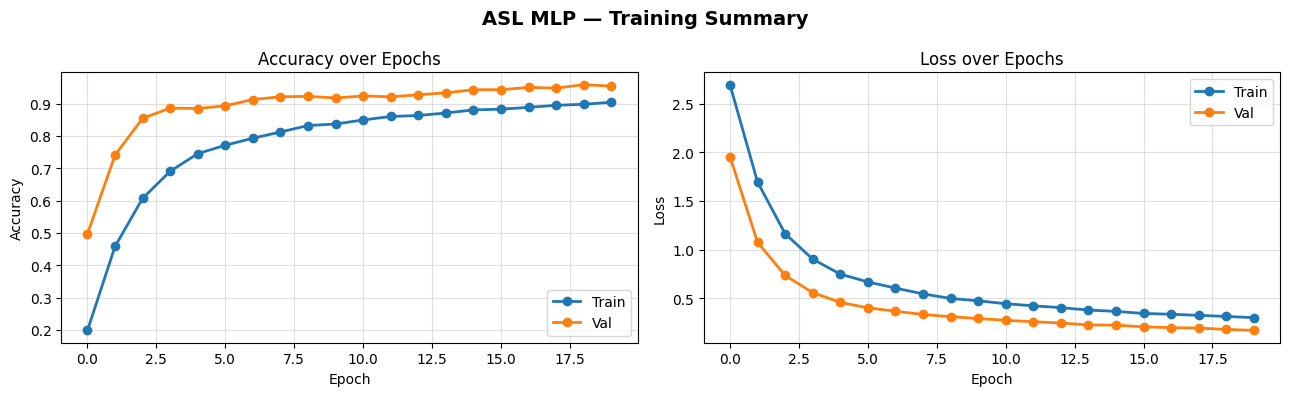

✅ Training curves saved → /kaggle/working/training_curves.png


In [37]:
# ── Final Evaluation ──────────────────────────────────────────
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"✅ Final Results")
print(f"   Val Loss     : {val_loss:.4f}")
print(f"   Val Accuracy : {val_acc * 100:.2f}%")

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("ASL MLP — Training Summary", fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train', marker='o', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   marker='o', linewidth=2)
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(history.history['loss'],     label='Train', marker='o', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   marker='o', linewidth=2)
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved → /kaggle/working/training_curves.png")

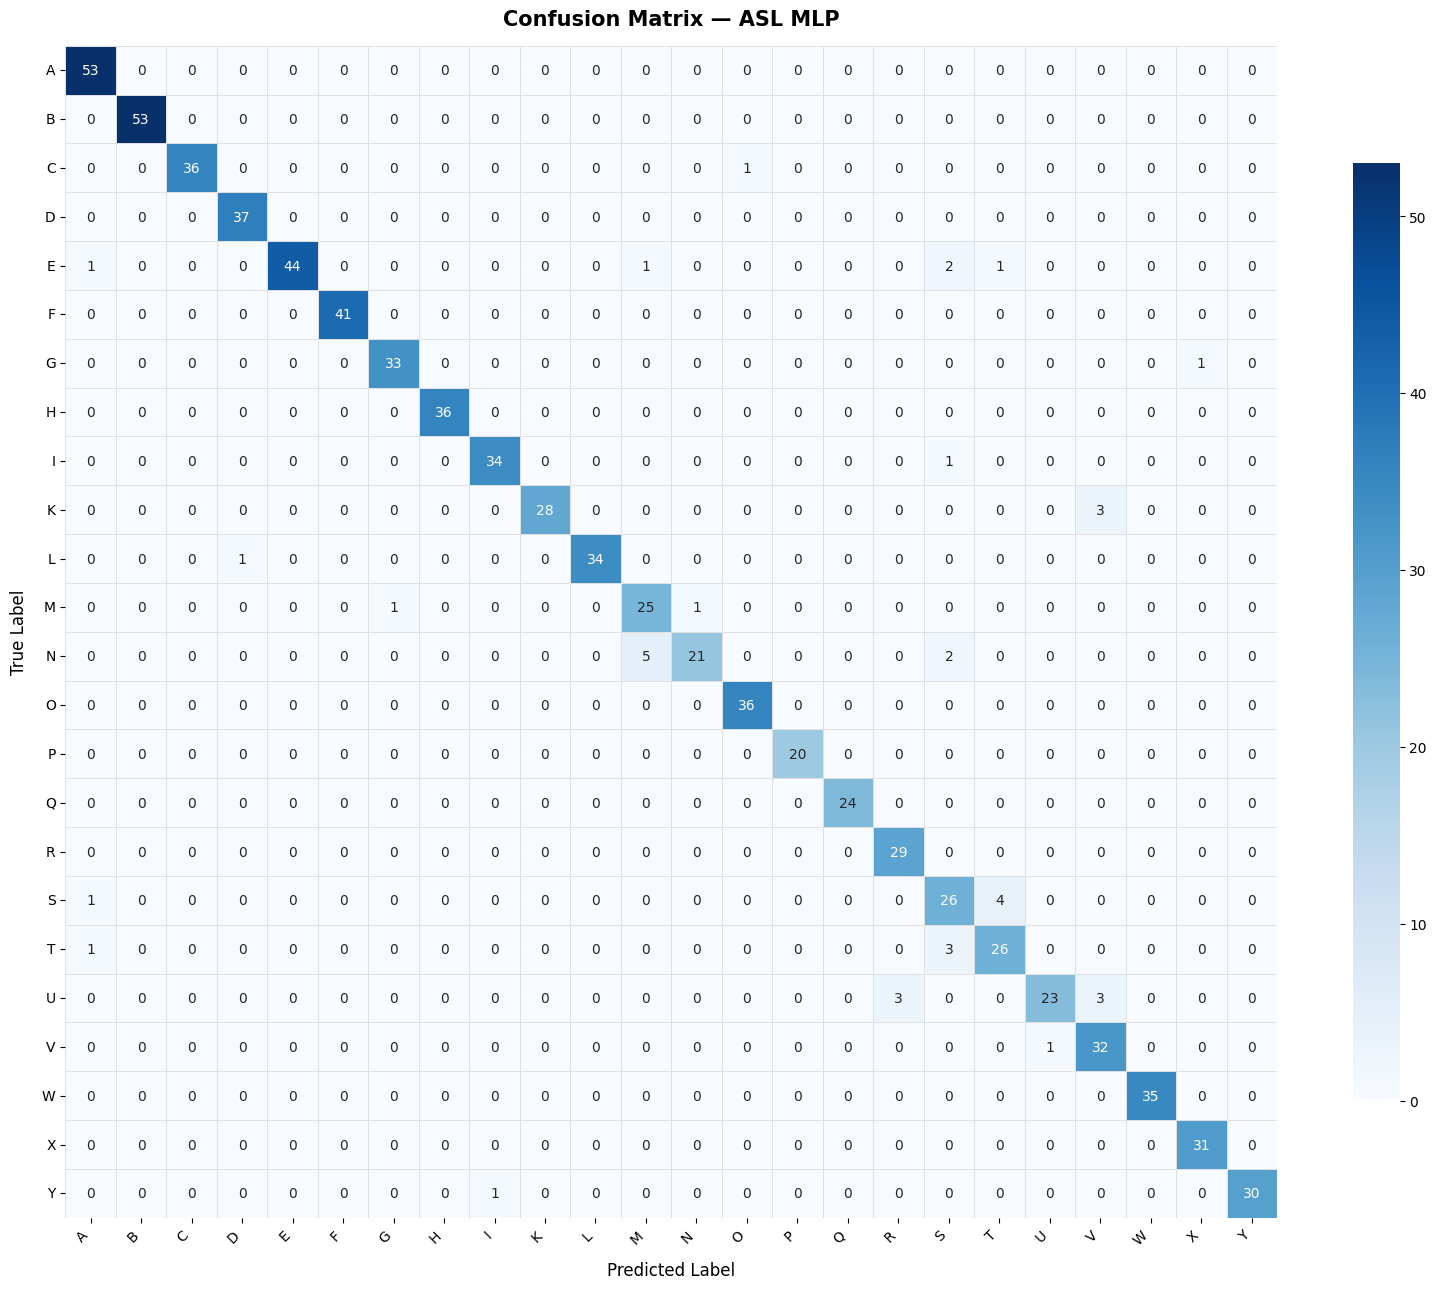

✅ Confusion matrix saved.


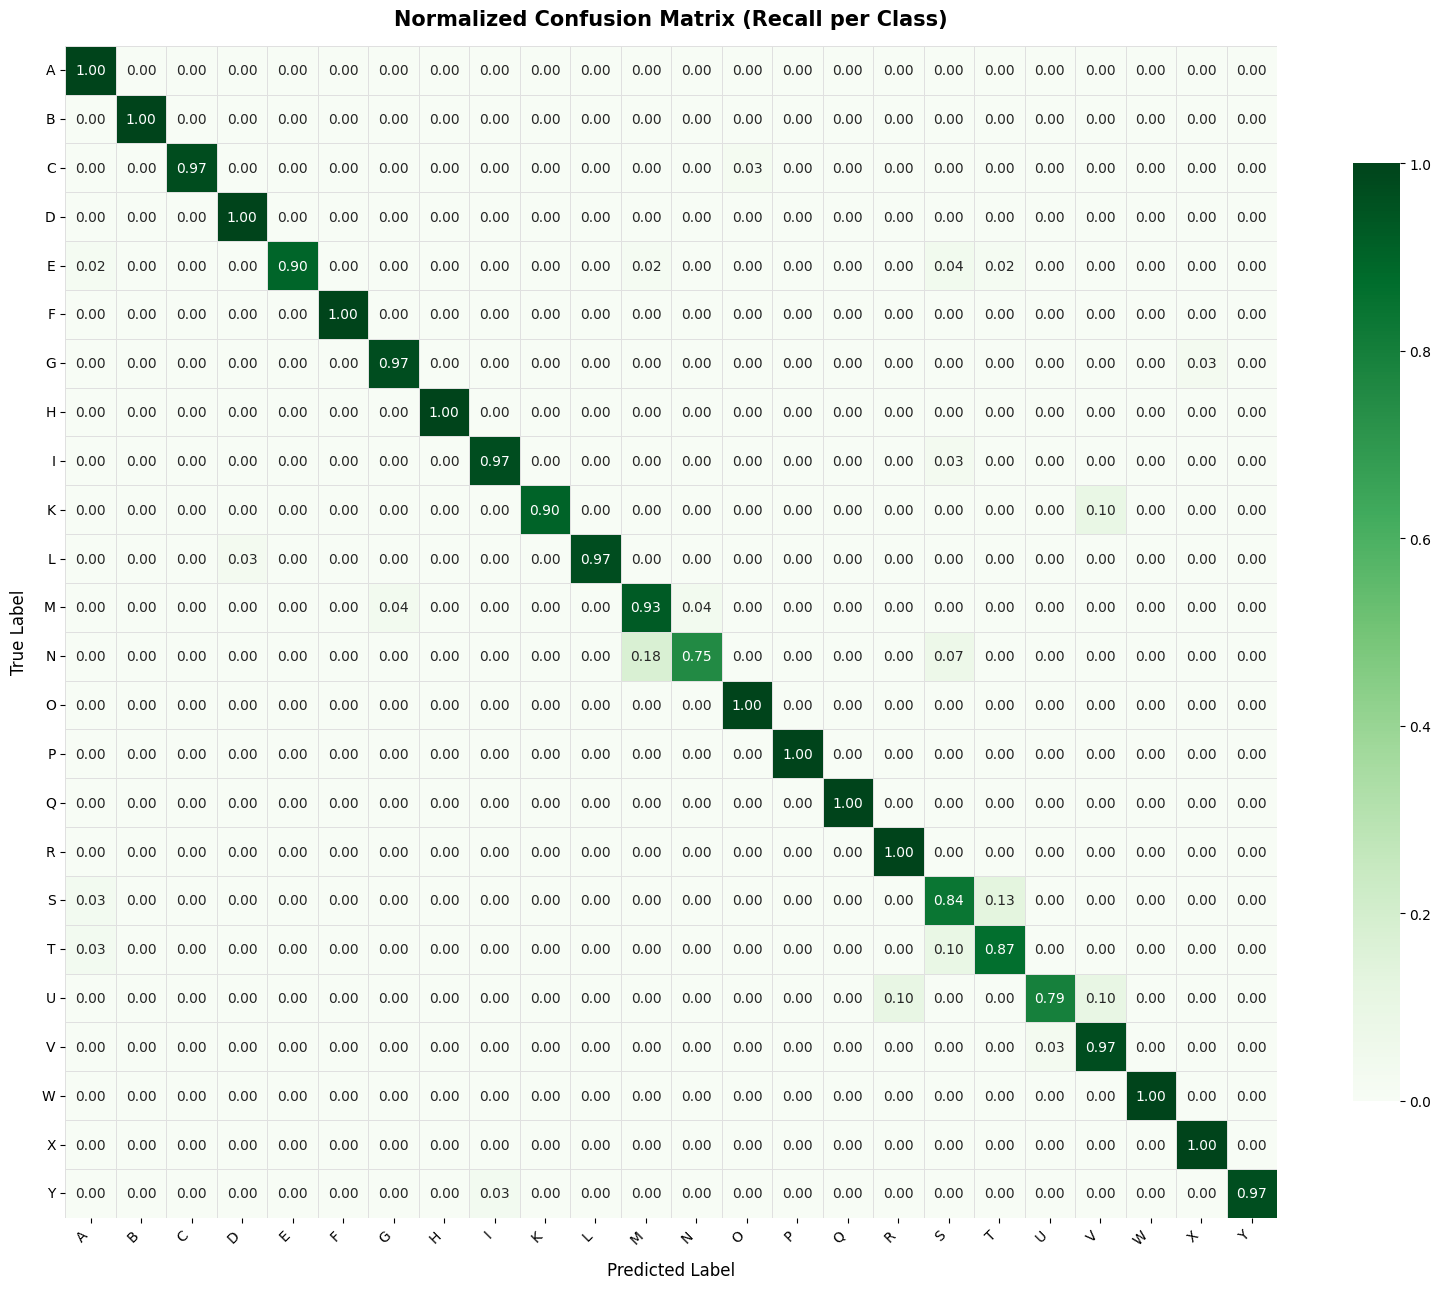

✅ Normalized confusion matrix saved.


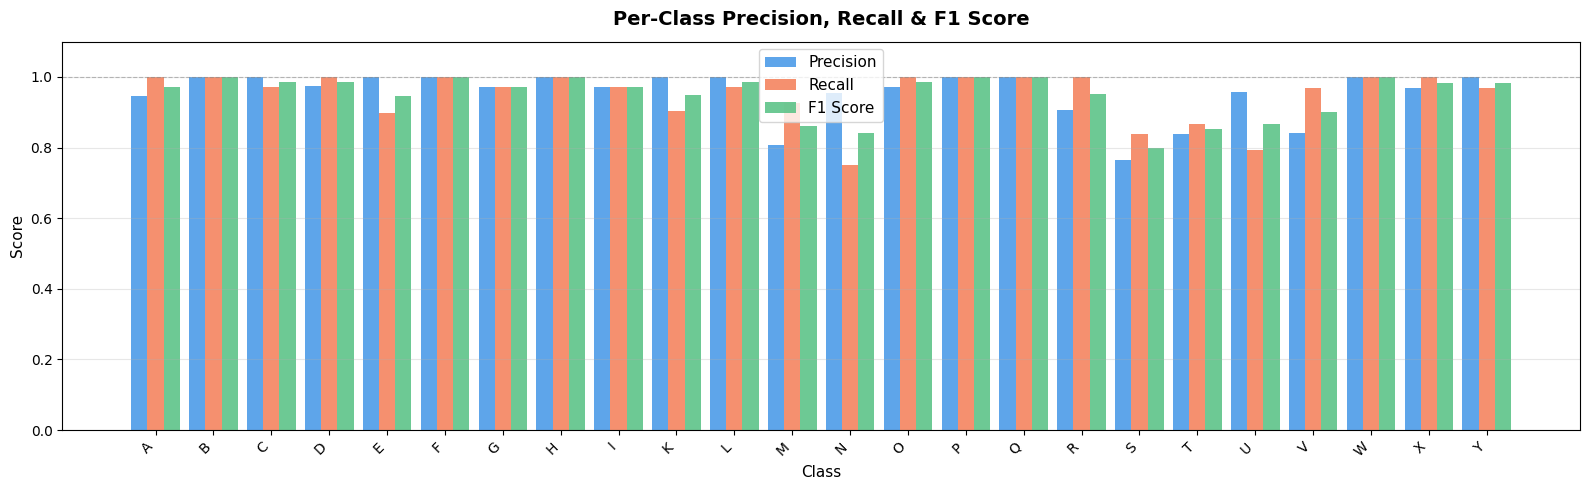

✅ Per-class metrics chart saved.


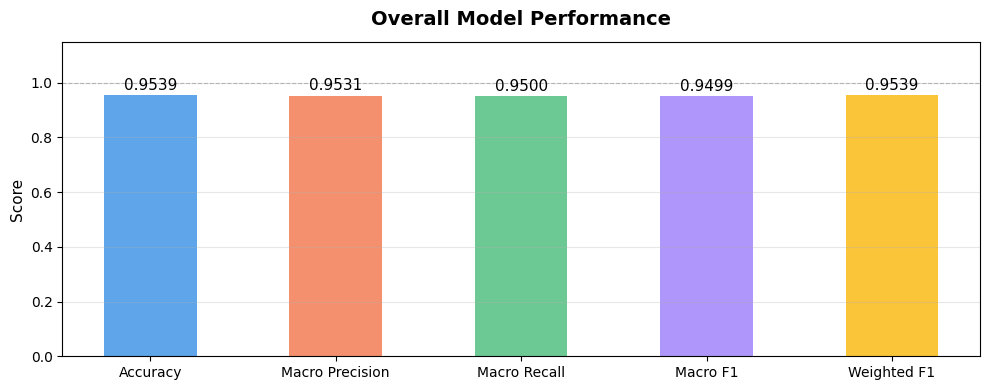

✅ Overall metrics chart saved.

📊 Classification Report:
              precision  recall  f1-score   support
A                0.9464  1.0000    0.9725   53.0000
B                1.0000  1.0000    1.0000   53.0000
C                1.0000  0.9730    0.9863   37.0000
D                0.9737  1.0000    0.9867   37.0000
E                1.0000  0.8980    0.9462   49.0000
F                1.0000  1.0000    1.0000   41.0000
G                0.9706  0.9706    0.9706   34.0000
H                1.0000  1.0000    1.0000   36.0000
I                0.9714  0.9714    0.9714   35.0000
K                1.0000  0.9032    0.9492   31.0000
L                1.0000  0.9714    0.9855   35.0000
M                0.8065  0.9259    0.8621   27.0000
N                0.9545  0.7500    0.8400   28.0000
O                0.9730  1.0000    0.9863   36.0000
P                1.0000  1.0000    1.0000   20.0000
Q                1.0000  1.0000    1.0000   24.0000
R                0.9062  1.0000    0.9508   29.0000
S      

In [39]:
# ── Cell: Full Evaluation — Confusion Matrix + Charts ────────

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# ── Config ────────────────────────────────────────────────────
SAVE_CSV     = True
SAVE_FIGURES = True
OUTPUT_DIR   = "/kaggle/working/"

# ── Predict ───────────────────────────────────────────────────
y_prob     = model.predict(X_val, verbose=0)
y_pred_cls = np.argmax(y_prob, axis=1)
y_true_cls = np.argmax(y_val,  axis=1)

labels       = sorted(label_map.keys())
target_names = [label_map[i] for i in labels]

# ── 1. Confusion Matrix Heatmap ───────────────────────────────
cm = confusion_matrix(y_true_cls, y_pred_cls, labels=labels)

plt.figure(figsize=(16, 13))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    linewidths=0.5,
    linecolor='#e0e0e0',
    cbar_kws={'shrink': 0.8}
)
plt.title("Confusion Matrix — ASL MLP", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
plt.ylabel("True Label",      fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0,  fontsize=10)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f"{OUTPUT_DIR}confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved.")

# ── 2. Normalized Confusion Matrix (%) ───────────────────────
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(16, 13))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=target_names,
    yticklabels=target_names,
    linewidths=0.5,
    linecolor='#e0e0e0',
    vmin=0, vmax=1,
    cbar_kws={'shrink': 0.8}
)
plt.title("Normalized Confusion Matrix (Recall per Class)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
plt.ylabel("True Label",      fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0,  fontsize=10)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f"{OUTPUT_DIR}confusion_matrix_normalized.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Normalized confusion matrix saved.")

# ── 3. Per-Class Precision, Recall, F1 Bar Chart ─────────────
precision = precision_score(y_true_cls, y_pred_cls, labels=labels, average=None, zero_division=0)
recall    = recall_score(   y_true_cls, y_pred_cls, labels=labels, average=None, zero_division=0)
f1        = f1_score(       y_true_cls, y_pred_cls, labels=labels, average=None, zero_division=0)

x     = np.arange(len(target_names))
width = 0.28

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width, precision, width, label='Precision', color='#4C9BE8', alpha=0.9)
ax.bar(x,         recall,    width, label='Recall',    color='#F4845F', alpha=0.9)
ax.bar(x + width, f1,        width, label='F1 Score',  color='#5DC389', alpha=0.9)

ax.set_title("Per-Class Precision, Recall & F1 Score", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Class", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(target_names, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f"{OUTPUT_DIR}per_class_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Per-class metrics chart saved.")

# ── 4. Overall Metrics Summary Bar ───────────────────────────
overall_metrics = {
    'Accuracy'         : np.mean(y_pred_cls == y_true_cls),
    'Macro Precision'  : precision_score(y_true_cls, y_pred_cls, average='macro',    zero_division=0),
    'Macro Recall'     : recall_score(   y_true_cls, y_pred_cls, average='macro',    zero_division=0),
    'Macro F1'         : f1_score(       y_true_cls, y_pred_cls, average='macro',    zero_division=0),
    'Weighted F1'      : f1_score(       y_true_cls, y_pred_cls, average='weighted', zero_division=0),
}

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    overall_metrics.keys(),
    overall_metrics.values(),
    color=['#4C9BE8', '#F4845F', '#5DC389', '#A78BFA', '#FBBF24'],
    alpha=0.9, width=0.5
)
for bar, val in zip(bars, overall_metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='500')

ax.set_title("Overall Model Performance", fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f"{OUTPUT_DIR}overall_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Overall metrics chart saved.")

# ── 5. Classification Report Table ───────────────────────────
report = classification_report(
    y_true_cls, y_pred_cls,
    labels=labels,
    target_names=target_names,
    zero_division=0,
    output_dict=True
)
df_report = pd.DataFrame(report).T.round(4)
print("\n📊 Classification Report:")
print(df_report.to_string())

# ── 6. Save Predictions CSV ───────────────────────────────────
if SAVE_CSV:
    df_preds = pd.DataFrame({
        "True_Label_Index" : y_true_cls,
        "True_Label"       : [label_map[i] for i in y_true_cls],
        "Pred_Label_Index" : y_pred_cls,
        "Pred_Label"       : [label_map[i] for i in y_pred_cls],
        "Correct"          : y_true_cls == y_pred_cls
    })
    csv_path = f"{OUTPUT_DIR}asl_predictions_normalized.csv"
    df_preds.to_csv(csv_path, index=False)
    print(f"\n✅ Predictions saved → {csv_path}")
    print(f"   Total predictions : {len(df_preds)}")
    print(f"   Correct           : {df_preds['Correct'].sum()}")
    print(f"   Wrong             : {(~df_preds['Correct']).sum()}")

# ── Summary ───────────────────────────────────────────────────
print("\n" + "="*50)
print("📈 FINAL MODEL SUMMARY")
print("="*50)
for k, v in overall_metrics.items():
    print(f"   {k:<20} : {v*100:.2f}%")
print("="*50)

##  Verify Output Files

In [38]:
import os

output_files = [
    MODEL_SAVE_PATH,
    LABELS_JSON_PATH,
    "/kaggle/working/training_curves.png"
]

print("📁 Output files in /kaggle/working/:")
for f in output_files:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) / 1024 if exists else 0
    status = f"✅  {size:.1f} KB" if exists else "❌  NOT FOUND"
    print(f"   {os.path.basename(f):40s} {status}")

📁 Output files in /kaggle/working/:
   asl_mlp_normalized.keras                 ✅  240.1 KB
   class_indices_normalized.json            ✅  0.3 KB
   training_curves.png                      ✅  88.4 KB
